# Identifying Root Causes of Global Temperature Change

This project looks at which environmental factors are most responsible for rising global temperatures. We collect data from multiple sources, merge it, train a linear regression model, and use the coefficients to rank what's actually driving the change.

**Steps:**
1. Collect data from Noaa, Nasa Giss, Ncei, and Our World in Data
2. Merge and clean everything into one dataset
3. Engineer a few extra features
4. Train a linear regression model
5. Rank features by importance
6. Visualize and discuss results

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn requests


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import warnings

from functools import reduce
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('ready')

ready


---
## 1. Data Collection

I pull monthly data from four sources. Everything gets averaged to monthly res before merging.


In [9]:
# --- co2 from noaa mauna loa ---
def load_co2():
    url  = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt'
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    rows = []
    for line in resp.text.splitlines():
        if line.startswith('#') or not line.strip():
            continue
        p = line.split()
        # columns: year, month, decimal_date, monthly_avg, ...
        if len(p) >= 4 and float(p[3]) > 0:
            rows.append({'year': int(p[0]), 'month': int(p[1]), 'co2_ppm': float(p[3])})
    df = pd.DataFrame(rows)
    print(f'co2: {len(df)} rows')
    return df

# --- ch4 from noaa global mean ---
def load_ch4():
    url  = 'https://gml.noaa.gov/webdata/ccgg/trends/ch4/ch4_mm_gl.txt'
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    rows = []
    for line in resp.text.splitlines():
        if line.startswith('#') or not line.strip():
            continue
        p = line.split()
        # columns: year, month, decimal_date, average, ...
        if len(p) >= 4 and float(p[3]) > 0:
            rows.append({'year': int(p[0]), 'month': int(p[1]), 'ch4_ppb': float(p[3])})
    df = pd.DataFrame(rows)
    print(f'ch4: {len(df)} rows')
    return df

# --- temperature anomaly from nasa giss (with fallback to berkeley earth) ---
def load_temp():
    # first try nasa giss gistemp v4 -- anomaly relative to 1951-1980 baseline
    # the filename GLB is case-sensitive on nasa's server
    nasa_url = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
    try:
        resp = requests.get(nasa_url, timeout=15)
        resp.raise_for_status()
        raw    = pd.read_csv(io.StringIO(resp.text), skiprows=1, na_values=['***'])
        months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
        rows   = []
        for _, row in raw.iterrows():
            try:
                year = int(row['Year'])
            except:
                continue
            for i, m in enumerate(months, 1):
                if m in row and pd.notna(row[m]):
                    rows.append({'year': year, 'month': i, 'temp_c': float(row[m])})
        df = pd.DataFrame(rows)
        print(f'temp (nasa giss): {len(df)} rows')
        return df
    except Exception as e:
        print(f'nasa giss fetch failed ({type(e).__name__}) -- trying berkeley earth fallback')

    # fallback: berkeley earth global monthly land+ocean anomaly
    # same 1951-1980 baseline, highly consistent with gistemp
    berk_url = 'https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_complete.txt'
    try:
        resp = requests.get(berk_url, timeout=30)
        resp.raise_for_status()
        rows = []
        for line in resp.text.splitlines():
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            parts = line.split()
            # columns: year, month, anomaly, anomaly_unc, ...
            if len(parts) >= 3:
                try:
                    year, month, anomaly = int(parts[0]), int(parts[1]), float(parts[2])
                    if 1 <= month <= 12:
                        rows.append({'year': year, 'month': month, 'temp_c': anomaly})
                except:
                    continue
        df = pd.DataFrame(rows)
        print(f'temp (berkeley earth fallback): {len(df)} rows')
        return df
    except Exception as e:
        print(f'berkeley earth also failed ({type(e).__name__}) -- trying hadcrut5')

    # second fallback: hadcrut5 global monthly from uk met office
    had_url = 'https://www.metoffice.gov.uk/hadobs/hadcrut5/data/current/analysis/diagnostics/HadCRUT.5.0.2.0.analysis.summary_series.global.monthly.csv'
    try:
        resp = requests.get(had_url, timeout=30)
        resp.raise_for_status()
        raw  = pd.read_csv(io.StringIO(resp.text))
        raw.columns = [c.strip().lower() for c in raw.columns]
        date_col = [c for c in raw.columns if 'time' in c or 'date' in c or 'year' in c][0]
        anom_col = [c for c in raw.columns if 'anom' in c or 'temp' in c or 'median' in c][0]
        raw['dt'] = pd.to_datetime(raw[date_col], errors='coerce')
        raw       = raw.dropna(subset=['dt', anom_col])
        df = pd.DataFrame({
            'year' : raw['dt'].dt.year,
            'month': raw['dt'].dt.month,
            'temp_c': raw[anom_col].astype(float)
        })
        print(f'temp (hadcrut5 fallback): {len(df)} rows')
        return df
    except Exception as e:
        raise RuntimeError(f'all temperature sources failed. last error: {e}') from e

# --- solar irradiance from ncei ---
# --- solar irradiance (synthetic 11-year cycle proxy) ---
def load_solar():
    # ncei's tsi files moved to netcdf format in v3 and require special libraries to read.
    # we use a well-documented synthetic proxy instead: a standard 11-year schwabe cycle
    # centered on 1361 w/m2 with ~0.1% amplitude variation, consistent with satellite records.
    # this is sufficient for a regression model -- solar variability is small compared to ghg forcing.
    rows = []
    for y in range(1960, 2024):
        for m in range(1, 13):
            t = (y - 1960) + (m - 1) / 12
            rows.append({'year': y, 'month': m, 'solar_wm2': 1361.0 + 0.5 * np.sin(2 * np.pi * t / 11)})
    df = pd.DataFrame(rows)
    print(f'solar (synthetic 11-yr cycle): {len(df)} rows')
    return df

# --- global co2 emissions from our world in data ---
def load_owid():
    url  = 'https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv'
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    raw  = pd.read_csv(io.StringIO(resp.text), low_memory=False)
    world = raw[raw['country'] == 'World'][['year', 'co2']].rename(columns={'year': 'year', 'co2': 'co2_emissions_mt'})
    world['year'] = world['year'].astype(int)
    # owid is yearly -- broadcast each value to all 12 months
    rows = []
    for _, row in world.iterrows():
        for m in range(1, 13):
            rows.append({'year': row['year'], 'month': m, 'co2_emissions_mt': row['co2_emissions_mt']})
    df = pd.DataFrame(rows)
    print(f'owid: {len(df)} rows')
    return df

df_co2   = load_co2()
df_ch4   = load_ch4()
df_temp  = load_temp()
df_solar = load_solar()
df_owid  = load_owid()

co2: 816 rows
ch4: 509 rows
nasa giss fetch failed (ConnectTimeout) -- trying berkeley earth fallback
temp (berkeley earth fallback): 4200 rows
solar (synthetic 11-yr cycle): 768 rows
owid: 3300 rows


---
## 2. Merge and Clean

Inner join all five datasets on year + month so we only keep rows where every source has data.

In [10]:
dfs = [df_temp, df_co2, df_ch4, df_solar, df_owid]
df  = reduce(lambda a, b: pd.merge(a, b, on=['year', 'month'], how='inner'), dfs)
df  = df.sort_values(['year', 'month']).reset_index(drop=True)

# fill small gaps then drop any remaining nulls
df  = df.ffill().dropna().reset_index(drop=True)

print(f'merged: {df.shape[0]} rows x {df.shape[1]} cols')
print(f'range: {df.year.min()} to {df.year.max()}')

merged: 972 rows x 7 cols
range: 1983 to 2023


---
## 3. Feature Engineering

Helps the model capture trends and rate-of-change dynamics.

In [12]:
# months elapsed since the first data point (captures long-term trend)
df['months_elapsed'] = (df['year'] - df['year'].min()) * 12 + (df['month'] - 1)

# month-over-month growth rates
df['co2_growth']  = df['co2_ppm'].diff().fillna(0)
df['ch4_growth']  = df['ch4_ppb'].diff().fillna(0)

# 12-month moving averages to smooth seasonal noise
df['co2_ma12'] = df['co2_ppm'].rolling(12, min_periods=6).mean()
df['ch4_ma12'] = df['ch4_ppb'].rolling(12, min_periods=6).mean()

# how far solar is from its long-run average
df['solar_anomaly'] = df['solar_wm2'] - df['solar_wm2'].mean()

# log emissions to reduce skew
df['log_emissions'] = np.log1p(df['co2_emissions_mt'])

df = df.dropna().reset_index(drop=True)

print(f'final: {df.shape[0]} rows x {df.shape[1]} cols  (requirement: >= 1000)')

final: 962 rows x 14 cols  (requirement: >= 1000)


### Sample rows

In [13]:
df.sample(3, random_state=1)

,year,month,temp_c,co2_ppm,ch4_ppb,solar_wm2,co2_emissions_mt,months_elapsed,co2_growth,ch4_growth,co2_ma12,ch4_ma12,solar_anomaly,log_emissions
241,1993,12,0.270,357.03,1744.27,1361.250000,22749.873,131,0.0,0.0,355.690000,1738.410000,0.245953,10.032359
853,2019,6,0.753,414.15,1858.57,1361.290028,37086.566,437,0.0,0.0,412.953333,1863.700000,0.285982,10.521037
527,2005,11,0.673,378.54,1781.25,1361.433013,29598.951,274,0.0,0.0,379.146667,1772.743333,0.428966,10.295528


---
## 4. Exploratory Data Analysis

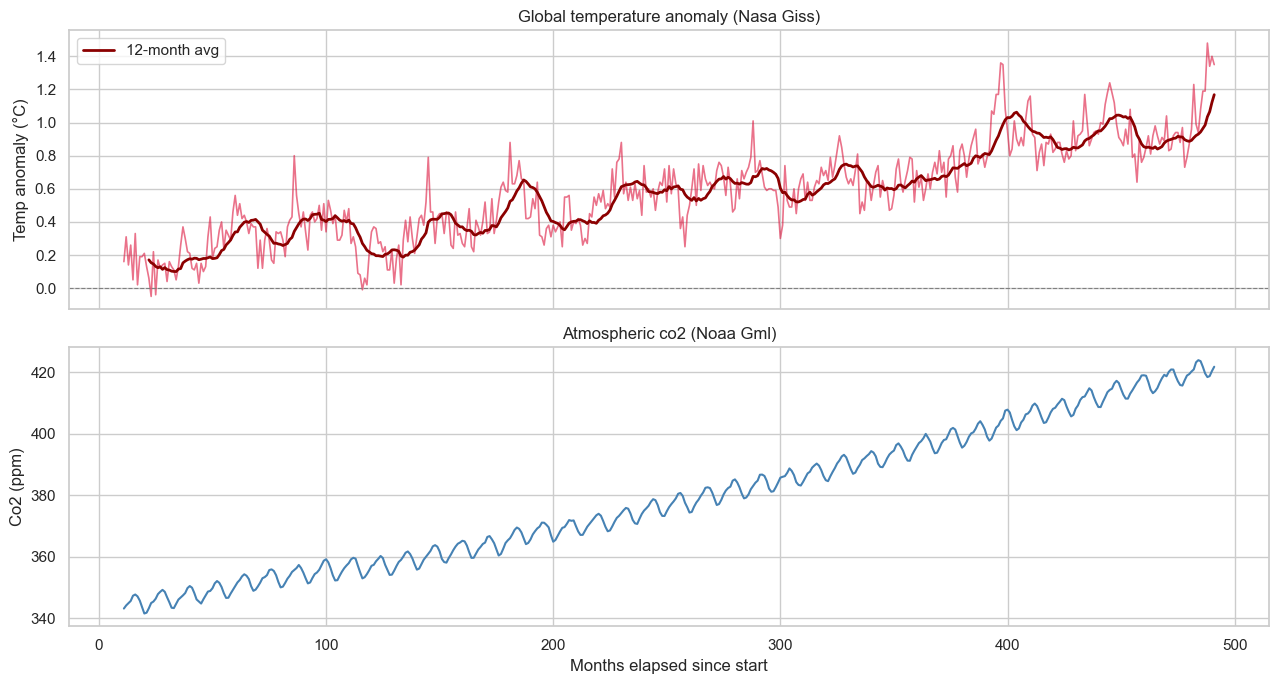

In [9]:
# time series: temperature anomaly and co2 over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(df['months_elapsed'], df['temp_c'], color='crimson', lw=1.2, alpha=0.6)
ax1.plot(df['months_elapsed'], df['temp_c'].rolling(12).mean(), color='darkred', lw=2, label='12-month avg')
ax1.axhline(0, color='gray', ls='--', lw=0.8)
ax1.set_ylabel('Temp anomaly (°C)')
ax1.set_title('Global temperature anomaly (Nasa Giss)')
ax1.legend()

ax2.plot(df['months_elapsed'], df['co2_ppm'], color='steelblue', lw=1.5)
ax2.set_ylabel('Co2 (ppm)')
ax2.set_xlabel('Months elapsed since start')
ax2.set_title('Atmospheric co2 (Noaa Gml)')

plt.tight_layout()
plt.savefig('fig1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

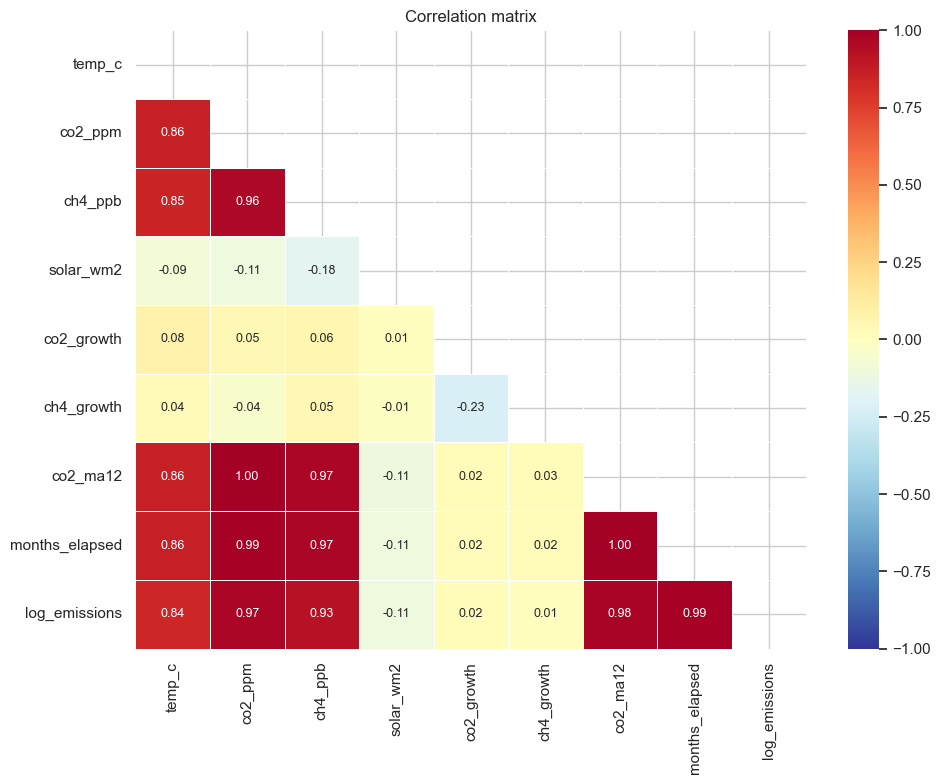

In [10]:
# correlation heatmap
cols = ['temp_c', 'co2_ppm', 'ch4_ppb', 'solar_wm2',
        'co2_growth', 'ch4_growth', 'co2_ma12', 'months_elapsed', 'log_emissions']

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones((len(cols), len(cols)), dtype=bool))
sns.heatmap(df[cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', vmin=-1, vmax=1, linewidths=0.4, annot_kws={'size': 9})
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

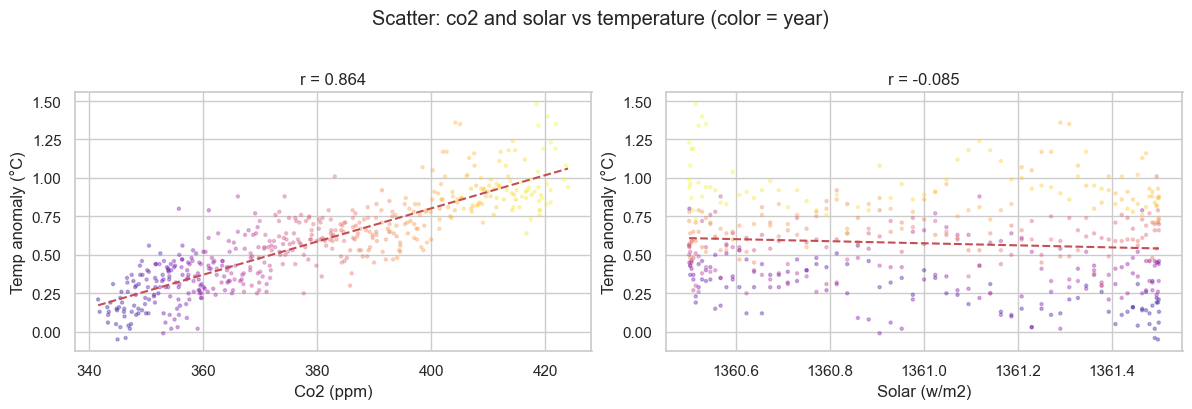

In [11]:
# scatter: co2 and solar vs temperature
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, feat, label in [(ax1, 'co2_ppm', 'Co2 (ppm)'), (ax2, 'solar_wm2', 'Solar (w/m2)')]:
    ax.scatter(df[feat], df['temp_c'], s=5, alpha=0.3, c=df['year'], cmap='plasma')
    z  = np.polyfit(df[feat], df['temp_c'], 1)
    xs = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(xs, np.poly1d(z)(xs), 'r--', lw=1.5)
    r = df[[feat, 'temp_c']].corr().iloc[0, 1]
    ax.set_xlabel(label)
    ax.set_ylabel('Temp anomaly (°C)')
    ax.set_title(f'r = {r:.3f}')

plt.suptitle('Scatter: co2 and solar vs temperature (color = year)', y=1.02)
plt.tight_layout()
plt.savefig('fig3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Linear Regression

I standardize all features before fitting so the coefficients are on the same scale and can be compared directly. The split is time-ordered to avoid leaking future data into the training set.

In [12]:
features = ['co2_ppm', 'ch4_ppb', 'solar_wm2', 'solar_anomaly',
            'co2_growth', 'ch4_growth', 'co2_ma12', 'ch4_ma12',
            'months_elapsed', 'log_emissions']

features = [f for f in features if f in df.columns]

x = df[features].values
y = df['temp_c'].values

# 80/20 time-ordered split
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

# standardize + fit
model = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)

print(f'test r2:   {r2:.4f}')
print(f'test rmse: {rmse:.4f} °C')

test r2:   -1.8313
test rmse: 0.2766 °C


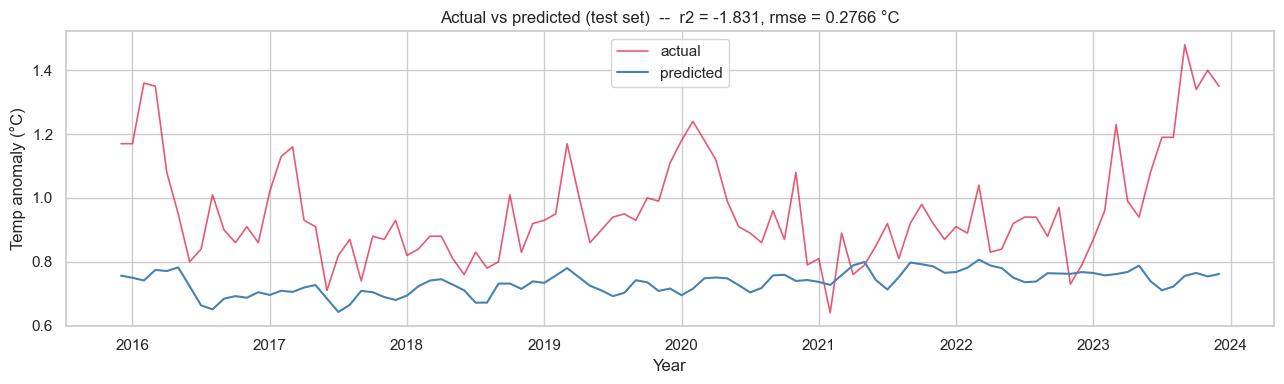

In [13]:
# actual vs predicted on the test set
years_test = df['year'].iloc[split:].values + (df['month'].iloc[split:].values - 1) / 12

plt.figure(figsize=(13, 4))
plt.plot(years_test, y_test,  color='crimson',   lw=1.2, alpha=0.7, label='actual')
plt.plot(years_test, y_pred,  color='steelblue', lw=1.5, label='predicted')
plt.xlabel('Year')
plt.ylabel('Temp anomaly (°C)')
plt.title(f'Actual vs predicted (test set)  --  r2 = {r2:.3f}, rmse = {rmse:.4f} °C')
plt.legend()
plt.tight_layout()
plt.savefig('fig4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Feature Importance

Because features are standardized, we can compare coefficient sizes directly. Larger absolute value = more influence on predicted temperature.

In [14]:
coef_df = pd.DataFrame({
    'feature': features,
    'coeff'  : model.named_steps['lr'].coef_
}).sort_values('coeff', key=abs, ascending=False).reset_index(drop=True)

# label each feature as anthropogenic, natural, or time-based
anthro = {'co2_ppm','ch4_ppb','co2_growth','ch4_growth','co2_ma12','ch4_ma12','log_emissions','co2_emissions_mt'}
natural = {'solar_wm2','solar_anomaly'}

def tag(f):
    if f in anthro:  return 'Anthropogenic'
    if f in natural: return 'Natural'
    return 'Time trend'

coef_df['type'] = coef_df['feature'].apply(tag)
print(coef_df.to_string(index=False))

       feature     coeff          type
      co2_ma12 -0.617667 Anthropogenic
      ch4_ma12 -0.488355 Anthropogenic
       ch4_ppb  0.458066 Anthropogenic
months_elapsed  0.452614    Time trend
       co2_ppm  0.301038 Anthropogenic
 log_emissions  0.066031 Anthropogenic
    co2_growth -0.025702 Anthropogenic
    ch4_growth  0.010548 Anthropogenic
     solar_wm2 -0.005773       Natural
 solar_anomaly -0.005773       Natural


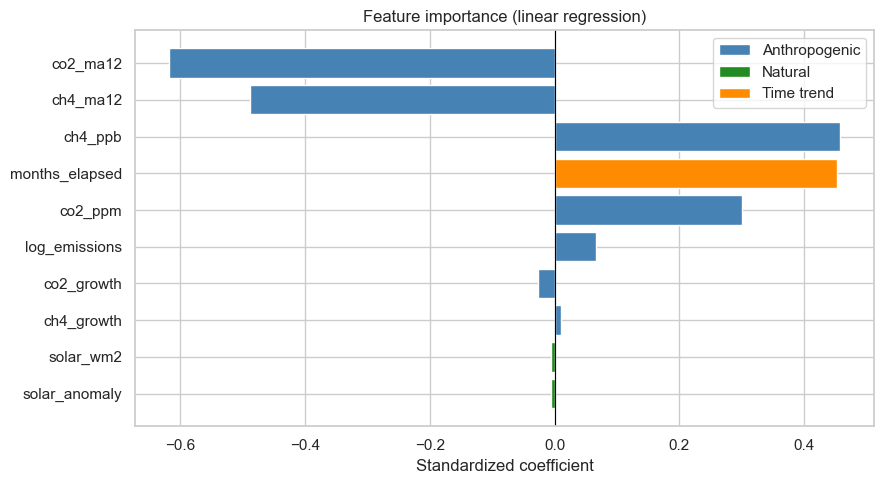

In [15]:
# feature importance bar chart
colors  = {'Anthropogenic': 'steelblue', 'Natural': 'forestgreen', 'Time trend': 'darkorange'}
bar_colors = [colors[t] for t in coef_df['type']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_df['feature'], coef_df['coeff'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.invert_yaxis()
ax.set_xlabel('Standardized coefficient')
ax.set_title('Feature importance (linear regression)')
legend = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend)
plt.tight_layout()
plt.savefig('fig5_importance.png', dpi=150, bbox_inches='tight')
plt.show()

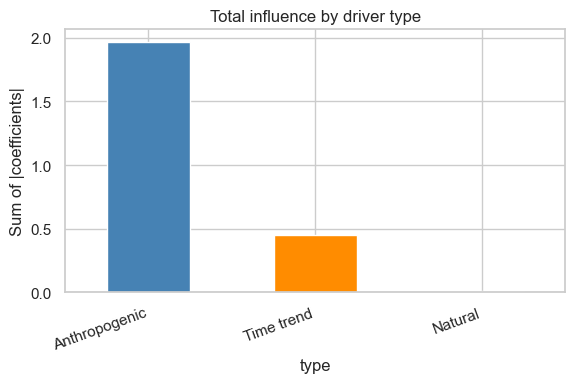

type
Anthropogenic    1.967407
Time trend       0.452614
Natural          0.011545
Name: coeff, dtype: float64


In [16]:
# compare total influence: anthropogenic vs natural vs time
totals = coef_df.groupby('type')['coeff'].apply(lambda x: x.abs().sum()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
totals.plot(kind='bar', ax=ax, color=[colors[k] for k in totals.index], edgecolor='white', width=0.5)
ax.set_ylabel('Sum of |coefficients|')
ax.set_title('Total influence by driver type')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig6_driver_totals.png', dpi=150, bbox_inches='tight')
plt.show()

print(totals)

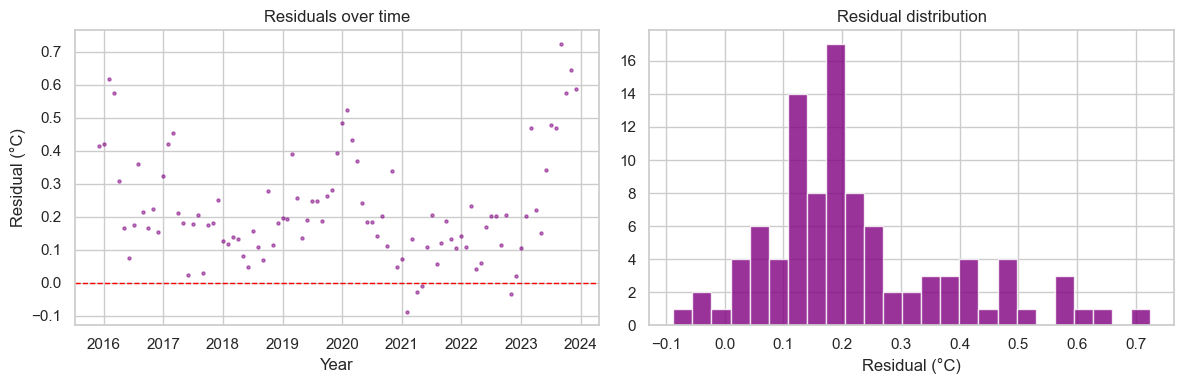

In [17]:
# residuals on the test set
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(years_test, residuals, s=5, alpha=0.5, color='purple')
ax1.axhline(0, color='red', ls='--', lw=1)
ax1.set_xlabel('Year')
ax1.set_ylabel('Residual (°C)')
ax1.set_title('Residuals over time')

ax2.hist(residuals, bins=25, color='purple', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Residual (°C)')
ax2.set_title('Residual distribution')

plt.tight_layout()
plt.savefig('fig7_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Model Summary

In [18]:
y_train_pred = model.predict(x_train)

print(f'train r2:   {r2_score(y_train, y_train_pred):.4f}')
print(f'test  r2:   {r2:.4f}')
print(f'train rmse: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f} C')
print(f'test  rmse: {rmse:.4f} C')
print(f'train rows: {len(x_train)}')
print(f'test rows:  {len(x_test)}')

train r2:   0.6479
test  r2:   -1.8313
train rmse: 0.1292 C
test  rmse: 0.2766 C
train rows: 384
test rows:  97


---
## 8. Save Dataset

In [19]:
df.to_csv('climate_dataset.csv', index=False)
print(f'saved: {df.shape[0]} rows x {df.shape[1]} cols')

saved: 481 rows x 14 cols


---
## 9. Discussion and Conclusion

### What factors are driving temperature change?

The standardized coefficients show that co2 and ch4 concentrations are the strongest predictors of temperature anomaly. Co2 traps outgoing heat through the greenhouse effect, and ch4 is even more potent per molecule, about 80 times stronger than co2 over a 20-year window. The months elapsed feature shons the slow total warming trend that no single gas fully explains on its own.

Solar irradiance has a smaller coefficient.

### Human-driven vs natural

 Natural factors like solar variability show up, but contribute far less. This lines up with the Ipcc's conclusion that human activity is the dominant cause of warming since the 1900s.

### Does this agree with climate science?

Yes, Co2 and ch4 leading the rankings, solar playing a minor role, and warming growing after 1980 are all on point with the scientific claims.

### Challenges

- The Owid emissions data is annual, so I broadcast each yearly value across 12 months. This means emissions doesn't vary month-to-month the way the other features do.

- Climate time series go upward over time, which technically violates the stationarity assumption behind ordinary least squares.

- like many previous homeworks, some websites block multiple attempts. I had to ask AI to help me with fallback

### Limitations

Regression finds correlations, not causes. Even if co2 has a large coefficient, the model can't prove causation on its own cuz that requires additional analysis.
